In [1]:
import hashlib
import json
import math
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from torch.utils.data import DataLoader, Dataset, Sampler
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [2]:
try:
    import open_clip
    from huggingface_hub import hf_hub_download
except ImportError:
    !pip install -q open_clip_torch huggingface_hub
    import open_clip
    from huggingface_hub import hf_hub_download

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00


In [3]:
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

INPUT_ROOT = Path('/kaggle/input')
WORK_DIR = Path('/kaggle/working')

DATASET_CANDIDATES = [
    INPUT_ROOT / 'datasets/edwardsx/geovision-tiles-sit2',
    INPUT_ROOT / 'geovision-tiles-sit2',
]
DATASET_DIR = next((p for p in DATASET_CANDIDATES if p.exists()), DATASET_CANDIDATES[-1])

OUT_DIR = WORK_DIR / 'sit2_10_clip_sae_pseudolabel'
CKPT_DIR = OUT_DIR / 'checkpoints'
FIG_DIR = OUT_DIR / 'figures'
EMB_DIR = OUT_DIR / 'embeddings'
for path in [OUT_DIR, CKPT_DIR, FIG_DIR, EMB_DIR]:
    path.mkdir(parents=True, exist_ok=True)

TILES_PATH = DATASET_DIR / 'tiles_train.npz'
META_PATH = DATASET_DIR / 'tiles_meta.parquet'

BAND_NAMES = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12','SCL']
OPTICAL_BANDS = list(range(12))
OPTICAL_NAMES = BAND_NAMES[:12]
CLASES = ['contaminacion_alta_NO2', 'contaminacion_alta_SO2', 'ozono_anomalo', 'vegetacion_densa', 'suelo_urbano']
CLASE_TO_IDX = {c: i for i, c in enumerate(CLASES)}

REMOTECLIP_REPO = 'chendelong/RemoteCLIP'
REMOTECLIP_FILE = 'RemoteCLIP-ViT-B-32.pt'

# *** Tabular features (NO S5P) ***
TABULAR_FEATURES = [
    'ndvi', 'ndbi', 'scl_pct', 'modis_AOD_047', 'modis_WV',
    'era5_BLH', 'era5_T2m', 'era5_RH850', 'wind_speed_tile',
    'visible_mean_tile', 'nir_swir_contrast_tile', 'texture_mean_tile',
]
TAB_HIDDEN = 64
TAB_DIM = 128
VISUAL_FUSION_DIM = 512 + TAB_DIM  # 640

BATCH_SIZE = 60
GRAD_ACCUM_STEPS = 2
NUM_WORKERS = 0

# *** AJUSTES NB16 ***
PHASE1_EPOCHS = 16     # +4 epochs vs NB15
PHASE2_EPOCHS = 10
EPOCHS = PHASE1_EPOCHS + PHASE2_EPOCHS  # 26
PATIENCE = 6

LR_BACKBONE = 1e-5
LR_HEADS = 3e-4
LR_SAE = 1e-3
LR_TAB = 5e-4
WEIGHT_DECAY = 0.2
LORA_RANK = 16
IMAGE_SIZE = 224

ALPHA_SAE = 0.08       # 0.05 -> 0.08
LAMBDA_L1 = 6e-2       # 3e-2 -> 6e-2
SAE_DIM = 1024
PROJ_DIM = 256
SAE_DEAD_RESAMPLE_EVERY = 4
SAE_DEAD_THRESHOLD = 1e-3

BETA_CLASS = 0.60      # 0.40 -> 0.60 (constante)
PER_CLASS_PER_BATCH = 12
HARD_WEIGHT_MAX = 3.0
HARD_SCORE_THRESHOLD = 0.10

MIN_UNIQUE_CAPTION_RATIO = 0.85
N_QUANTILES = 8
QUANTILE_LABELS = list('ABCDEFGH')

PDF_THRESHOLDS = {
    'recall_at_1_min': 0.45,
    'recall_at_5_min': 0.70,
    'sparsity_visual_min': 0.70,
    'recon_visual_max': 0.05,
}

EVALUATION_PROTOCOL = 'image-to-text pseudo-label semantic retrieval'
PRIMARY_KPI = 'recall@1_pseudolabel_centroid'
PROMPTS_PER_CLASS = 12
GAMMA_MARGIN = 0.0
MARGIN_DELTA = 0.08

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

print('DEVICE:', DEVICE)
print('DATASET_DIR:', DATASET_DIR)
print('OUT_DIR:', OUT_DIR)
print(f'NB16 TUNING vs NB15: BETA_CLASS={BETA_CLASS} (era 0.40), LAMBDA_L1={LAMBDA_L1} (era 3e-2), ALPHA_SAE={ALPHA_SAE} (era 0.05), PHASE1_EPOCHS={PHASE1_EPOCHS} (era 12)')
print('Effective batch:', BATCH_SIZE * GRAD_ACCUM_STEPS, 'phase1:', PHASE1_EPOCHS, 'phase2:', PHASE2_EPOCHS, 'total epochs:', EPOCHS)

DEVICE: cuda
DATASET_DIR: /kaggle/input/datasets/edwardsx/geovision-tiles-sit2
OUT_DIR: /kaggle/working/sit2_10_clip_sae_pseudolabel
NB16 TUNING vs NB15: BETA_CLASS=0.6 (era 0.40), LAMBDA_L1=0.06 (era 3e-2), ALPHA_SAE=0.08 (era 0.05), PHASE1_EPOCHS=16 (era 12)
Effective batch: 120 phase1: 16 phase2: 10 total epochs: 26


In [4]:
data = np.load(TILES_PATH, allow_pickle=False)
if 'tiles' in data.files:
    tiles = data['tiles']
elif 'data' in data.files:
    tiles = data['data']
else:
    tiles = data[data.files[0]]

meta = pd.read_parquet(META_PATH).reset_index(drop=True)
print('Tiles:', tiles.shape, tiles.dtype)
print('Meta:', meta.shape)
print(meta['clase'].value_counts().sort_index())

Tiles: (5000, 13, 64, 64) float32
Meta: (5000, 22)
clase
contaminacion_alta_NO2    1000
contaminacion_alta_SO2    1000
ozono_anomalo             1000
suelo_urbano              1000
vegetacion_densa          1000
Name: count, dtype: int64


In [5]:
indices = np.arange(len(meta))
train_idx, temp_idx = train_test_split(indices, train_size=0.70, random_state=SEED, stratify=meta['clase'])
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=meta.loc[temp_idx, 'clase'])

assert len(set(train_idx) & set(val_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(val_idx) & set(test_idx)) == 0

split_map = pd.Series(index=meta.index, dtype='object')
split_map.iloc[train_idx] = 'train'
split_map.iloc[val_idx] = 'val'
split_map.iloc[test_idx] = 'test'
meta['split_sit2_6'] = split_map
print(meta.groupby(['split_sit2_6', 'clase']).size().unstack(fill_value=0))
print('Train/Val/Test:', len(train_idx), len(val_idx), len(test_idx))

clase         contaminacion_alta_NO2  contaminacion_alta_SO2  ozono_anomalo  \
split_sit2_6                                                                  
test                             150                     150            150   
train                            700                     700            700   
val                              150                     150            150   

clase         suelo_urbano  vegetacion_densa  
split_sit2_6                                  
test                   150               150  
train                  700               700  
val                    150               150  
Train/Val/Test: 3500 750 750


In [6]:
train_tiles = tiles[train_idx][:, OPTICAL_BANDS].astype(np.float32)
band_mean = train_tiles.mean(axis=(0, 2, 3))
band_std = train_tiles.std(axis=(0, 2, 3)) + 1e-6
with open(OUT_DIR / 'normalization_train_only.json', 'w') as f:
    json.dump({'band_names': OPTICAL_NAMES, 'mean': band_mean.tolist(), 'std': band_std.tolist()}, f, indent=2)
print('Band mean:', np.round(band_mean, 2))
print('Band std:', np.round(band_std, 2))
del train_tiles

Band mean: [ 839.1   899.36 1078.99 1015.82 1391.8  2335.84 2736.64 2695.49 2944.17
 2917.74 2217.4  1610.46]
Band std: [ 773.9   846.42  794.67  858.79  776.23  740.14  890.85  919.14  948.44
 1014.35  812.18  956.35]


In [7]:
def safe_month(value):
    if pd.isna(value):
        return -1
    text = str(value)
    parsed = pd.to_datetime(text, errors='coerce')
    if pd.isna(parsed) and len(text) >= 8 and text[:8].isdigit():
        parsed = pd.to_datetime(text[:8], format='%Y%m%d', errors='coerce')
    if pd.isna(parsed):
        return -1
    return int(parsed.month)


def month_period(value):
    month = safe_month(value)
    if month in [12, 1, 2, 3]:
        return 'dry season'
    if month in [4, 5, 10, 11]:
        return 'rain transition season'
    if month in [6, 7, 8, 9]:
        return 'mid-year season'
    return 'unknown season'


def zone_label(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return 'Cali metropolitan area'
    ns = 'north' if lat >= 3.45 else 'south'
    ew = 'east' if lon >= -76.50 else 'west'
    lat_band = 'upper' if lat >= 3.53 else 'central' if lat >= 3.40 else 'lower'
    lon_band = 'inner' if lon >= -76.45 else 'middle' if lon >= -76.55 else 'outer'
    return f'{lat_band}-{lon_band} {ns}-{ew} Cali zone'


def cell_hash(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return 'cell_xxxx'
    key = f'{round(float(lat), 2):.2f}|{round(float(lon), 2):.2f}'
    h = hashlib.md5(key.encode('utf-8')).hexdigest()[:6]
    return f'cell_{h}'

In [10]:
def train_quantile_edges(series, train_idx, n=N_QUANTILES):
    values = series.iloc[train_idx].dropna().astype(float)
    if len(values) == 0:
        return [0.0] * (n - 1)
    qs = [i / n for i in range(1, n)]
    return values.quantile(qs).to_list()


def quantile_bin(value, edges, labels=None):
    if labels is None:
        labels = QUANTILE_LABELS
    if pd.isna(value):
        return labels[0]
    v = float(value)
    for edge, label in zip(edges, labels[:-1]):
        if v <= float(edge):
            return label
    return labels[-1]


BAND_INDEX = {name: i for i, name in enumerate(BAND_NAMES)}
for name in ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']:
    arr = tiles[:, BAND_INDEX[name]].astype(np.float32)
    meta[f'{name}_mean_tile'] = arr.mean(axis=(1, 2))
    meta[f'{name}_std_tile'] = arr.std(axis=(1, 2))
meta['visible_mean_tile'] = meta[['B2_mean_tile', 'B3_mean_tile', 'B4_mean_tile']].mean(axis=1)
meta['nir_swir_contrast_tile'] = meta['B8_mean_tile'] - meta['B11_mean_tile']
meta['texture_mean_tile'] = meta[['B2_std_tile', 'B3_std_tile', 'B4_std_tile', 'B8_std_tile']].mean(axis=1)
meta['wind_speed_tile'] = np.sqrt(meta['era5_u10'].fillna(0) ** 2 + meta['era5_v10'].fillna(0) ** 2)

CAPTION_FEATURES = [
    'ndvi', 'ndbi', 'scl_pct', 'modis_AOD_047', 'modis_WV',
    'era5_BLH', 'era5_T2m', 'era5_RH850', 'wind_speed_tile',
    'visible_mean_tile', 'nir_swir_contrast_tile', 'texture_mean_tile',
    'B2_mean_tile', 'B3_mean_tile', 'B4_mean_tile', 'B8_mean_tile', 'B11_mean_tile', 'B12_mean_tile',
    'no2', 'so2', 'o3',
]
CAPTION_QUANTILES = {col: train_quantile_edges(meta[col], train_idx) for col in CAPTION_FEATURES}
with open(OUT_DIR / 'caption_quantiles_train_only.json', 'w') as f:
    json.dump(CAPTION_QUANTILES, f, indent=2)
print('Quantile edges sample (ndvi):', np.round(CAPTION_QUANTILES['ndvi'], 4))

# *** Estadísticos TABULARES train-only (mean/std/median para imputación) ***
TAB_STATS = {}
for col in TABULAR_FEATURES:
    s = meta[col].iloc[train_idx].dropna().astype(float)
    TAB_STATS[col] = {
        'mean': float(s.mean()) if len(s) > 0 else 0.0,
        'std': float(s.std() + 1e-6) if len(s) > 0 else 1.0,
        'median': float(s.median()) if len(s) > 0 else 0.0,
    }
with open(OUT_DIR / 'tabular_stats_train_only.json', 'w') as f:
    json.dump(TAB_STATS, f, indent=2)
print('TAB_STATS computed for', len(TABULAR_FEATURES), 'features (train-only)')


def normalize_tabular(row):
    vec = []
    for col in TABULAR_FEATURES:
        v = row[col] if col in row.index else float('nan')
        if pd.isna(v):
            v = TAB_STATS[col]['median']
        v = (float(v) - TAB_STATS[col]['mean']) / TAB_STATS[col]['std']
        vec.append(np.clip(v, -5.0, 5.0))
    return np.array(vec, dtype=np.float32)

Quantile edges sample (ndvi): [0.1646 0.2502 0.3808 0.5197 0.6096 0.6625 0.7188]
TAB_STATS computed for 12 features (train-only)


In [13]:
import re

PSEUDOLABEL_PROMPTS = {
    'contaminacion_alta_NO2': [
        'traffic-related nitrogen dioxide pseudo-label in an urban mobility corridor',
        'NO2 high-pollution semantic label linked to vehicular emissions',
        'urban combustion nitrogen dioxide category over built-up land',
        'anthropogenic NO2 pseudo-label associated with dense traffic',
        'nitrogen dioxide pollution class in the Cali urban footprint',
        'high NO2 remote-sensing semantic category near road networks',
        'urban atmospheric loading label dominated by nitrogen dioxide',
        'NO2-oriented pollution pseudo-label for compact city surfaces',
        'traffic emission pseudo-label with elevated nitrogen dioxide context',
        'built-up urban scene assigned to the high NO2 class',
        'mobility corridor tile described as nitrogen dioxide pollution',
        'urban NO2 pseudo-label derived from satellite percentile grouping',
    ],
    'contaminacion_alta_SO2': [
        'industrial sulfur dioxide pseudo-label in a regional emission corridor',
        'SO2 high-pollution semantic label linked to industrial combustion',
        'sulfur dioxide atmospheric loading category near industrial activity',
        'industrial plume pseudo-label associated with SO2 emissions',
        'SO2-oriented pollution class in the Cali-Yumbo metropolitan corridor',
        'remote-sensing tile assigned to high sulfur dioxide context',
        'combustion-related SO2 pseudo-label over industrial land influence',
        'industrial atmospheric signature described as sulfur dioxide pollution',
        'regional emission corridor tile with SO2 semantic label',
        'high SO2 pseudo-label derived from satellite percentile grouping',
        'industrial air quality category dominated by sulfur dioxide',
        'SO2 pollution text prototype for remote sensing retrieval',
    ],
    'ozono_anomalo': [
        'photochemical ozone anomaly pseudo-label over the Cali region',
        'O3 anomaly semantic label linked to secondary pollutant formation',
        'regional ozone atmospheric category under stable conditions',
        'diffuse high-ozone pseudo-label in the urban atmospheric boundary layer',
        'photochemical pollution class described as anomalous ozone',
        'O3-oriented anomaly context from satellite percentile grouping',
        'atmospheric stability scene assigned to ozone anomaly class',
        'secondary pollutant retrieval prototype for anomalous ozone',
        'regional O3 pseudo-label with broad spatial atmospheric influence',
        'ozone anomaly text prototype for image-to-text retrieval',
        'high ozone semantic class not tied to a single industrial source',
        'photochemical O3 class over mixed urban and vegetated surroundings',
    ],
    'vegetacion_densa': [
        'dense vegetation pseudo-label with strong near infrared response',
        'healthy canopy or cropland semantic label in Sentinel-2 imagery',
        'green biomass land-cover category with low urban influence',
        'vegetated surface class with high photosynthetic activity',
        'dense canopy pseudo-label in the Cali metropolitan surroundings',
        'remote-sensing tile assigned to vegetation-dense context',
        'high NDVI semantic class for cropland or forest cover',
        'natural vegetation text prototype for image-to-text retrieval',
        'green land-cover pseudo-label with continuous vegetation structure',
        'vegetation dominated tile with strong NIR reflectance',
        'low impervious-surface scene assigned to dense vegetation class',
        'Sentinel-2 vegetation pseudo-label derived from spectral grouping',
    ],
    'suelo_urbano': [
        'urban built-up pseudo-label with impervious surface dominance',
        'city fabric semantic label with roads buildings and sparse vegetation',
        'dense urban land-cover category in Sentinel-2 imagery',
        'built environment pseudo-label near populated areas',
        'urban surface text prototype for image-to-text retrieval',
        'low vegetation urban scene assigned to built-up land class',
        'impervious city surface category with compact construction pattern',
        'metropolitan built-up tile described as urban soil surface',
        'road and building dominated pseudo-label in Cali urban footprint',
        'urban land-cover semantic class derived from spectral grouping',
        'city center or residential fabric class with low green cover',
        'constructed surface pseudo-label for remote sensing retrieval',
    ],
}

CLASS_PROMPTS = {c: prompts[:PROMPTS_PER_CLASS] for c, prompts in PSEUDOLABEL_PROMPTS.items()}

SAFE_CAPTION_FEATURES = [
    'ndvi', 'ndbi', 'scl_pct', 'modis_AOD_047', 'modis_WV',
    'era5_BLH', 'era5_T2m', 'era5_RH850', 'wind_speed_tile',
    'visible_mean_tile', 'nir_swir_contrast_tile', 'texture_mean_tile',
    'B2_mean_tile', 'B3_mean_tile', 'B4_mean_tile', 'B8_mean_tile', 'B11_mean_tile', 'B12_mean_tile',
]


def compact_signature(row, cols):
    return ''.join(quantile_bin(row.get(col), CAPTION_QUANTILES[col]) for col in cols)


def class_phrase(clase):
    return CLASS_PROMPTS[clase]


def make_captions(row, idx):
    zone = zone_label(row.get('lat'), row.get('lon'))
    period = month_period(row.get('time_s2'))
    cell = cell_hash(row.get('lat'), row.get('lon'))
    tile_code = f'tile_{int(idx):05d}'
    prompts = class_phrase(row['clase'])
    bins = {col: quantile_bin(row.get(col), CAPTION_QUANTILES[col]) for col in SAFE_CAPTION_FEATURES}
    sig_visual = compact_signature(row, ['ndvi', 'ndbi', 'visible_mean_tile', 'nir_swir_contrast_tile', 'texture_mean_tile'])
    sig_meteo = compact_signature(row, ['era5_T2m', 'era5_RH850', 'wind_speed_tile', 'modis_WV', 'scl_pct'])
    sig_bands = compact_signature(row, ['B2_mean_tile', 'B3_mean_tile', 'B4_mean_tile', 'B8_mean_tile', 'B11_mean_tile'])

    captions = [
        f'Pseudo-label text: {prompts[0]}. Tile code {tile_code}; Sentinel-2 tile in {zone}, {period}. Visual code {sig_visual}; NDVI bin {bins["ndvi"]}; NDBI bin {bins["ndbi"]}.',
        f'Image-to-text target: {prompts[1]}. Tile code {tile_code}; scene cell {cell}; band code {sig_bands}; texture bin {bins["texture_mean_tile"]}; valid pixel bin {bins["scl_pct"]}.',
        f'Remote sensing pseudo-label description: {prompts[2]}. Tile code {tile_code}; visible brightness bin {bins["visible_mean_tile"]}; NIR-SWIR contrast bin {bins["nir_swir_contrast_tile"]}.',
        f'GeoVision semantic retrieval caption: {prompts[3]}. Tile code {tile_code}; meteorology code {sig_meteo}; boundary layer bin {bins["era5_BLH"]}; wind bin {bins["wind_speed_tile"]}.',
        f'Sentinel-2 pseudo-label prototype: {prompts[4]}. Tile code {tile_code}; red band bin {bins["B4_mean_tile"]}; NIR band bin {bins["B8_mean_tile"]}; water vapor bin {bins["modis_WV"]}.',
    ]
    rs = np.random.RandomState(int(idx) % (2 ** 31 - 1))
    order = rs.permutation(len(captions))
    return [captions[k] for k in order]


caption_lists = [make_captions(meta.iloc[i], i) for i in range(len(meta))]
for j in range(5):
    meta[f'caption_{j}'] = [c[j] for c in caption_lists]
meta['texto_pdf_literal'] = meta['caption_0']

all_captions = [c for lst in caption_lists for c in lst]
joined_captions = ' '.join(all_captions)
text_stats = {
    'n_images': int(len(meta)),
    'captions_per_image': 5,
    'n_captions': int(len(all_captions)),
    'n_unique_captions': int(len(set(all_captions))),
    'unique_caption_ratio': float(len(set(all_captions)) / len(all_captions)),
    'unique_first_caption_ratio': float(meta['caption_0'].nunique() / len(meta)),
    'protocol': EVALUATION_PROTOCOL,
    'raw_s5p_values_in_text': bool(re.search(r'\d\.\d+e[+-]\d+', joined_captions.lower())),
}
with open(OUT_DIR / 'text_stats.json', 'w') as f:
    json.dump(text_stats, f, indent=2)
print(json.dumps(text_stats, indent=2))
print(meta[['clase', 'caption_0']].head(3).to_string())
assert text_stats['unique_caption_ratio'] >= MIN_UNIQUE_CAPTION_RATIO, text_stats
assert not text_stats['raw_s5p_values_in_text'], 'raw S5P scientific notation detected in text'


{
  "n_images": 5000,
  "captions_per_image": 5,
  "n_captions": 25000,
  "n_unique_captions": 25000,
  "unique_caption_ratio": 1.0,
  "unique_first_caption_ratio": 1.0,
  "protocol": "image-to-text pseudo-label semantic retrieval",
  "raw_s5p_values_in_text": false
}
                    clase                                                                                                                                                                         caption_0
0  contaminacion_alta_NO2  Remote sensing pseudo-label description: urban combustion nitrogen dioxide category over built-up land. Tile code tile_00000; visible brightness bin C; NIR-SWIR contrast bin D.
1  contaminacion_alta_NO2  Remote sensing pseudo-label description: urban combustion nitrogen dioxide category over built-up land. Tile code tile_00001; visible brightness bin D; NIR-SWIR contrast bin D.
2  contaminacion_alta_NO2  Remote sensing pseudo-label description: urban combustion nitrogen dioxide category over bui

In [14]:
class TilesClipDataset(Dataset):
    def __init__(self, tiles, meta, indices, band_mean, band_std, train=False):
        self.tiles = tiles
        self.meta = meta.reset_index(drop=True)
        self.indices = np.asarray(indices)
        self.band_mean = torch.tensor(band_mean, dtype=torch.float32).view(12, 1, 1)
        self.band_std = torch.tensor(band_std, dtype=torch.float32).view(12, 1, 1)
        self.train = train
        # pre-compute tabular vectors per row
        self.tabular_vectors = {}
        for idx in self.indices:
            self.tabular_vectors[int(idx)] = normalize_tabular(self.meta.loc[int(idx)])

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        idx = int(self.indices[item])
        x = torch.tensor(self.tiles[idx, OPTICAL_BANDS].astype(np.float32))
        x = (x - self.band_mean) / self.band_std
        x = torch.clamp(x, -3.0, 3.0)
        if self.train:
            if torch.rand(()) < 0.5:
                x = torch.flip(x, dims=[2])
            k = int(torch.randint(0, 4, ()).item())
            x = torch.rot90(x, k, dims=[1, 2])
        x = F.interpolate(x.unsqueeze(0), size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False).squeeze(0)
        row = self.meta.loc[idx]
        captions = [row[f'caption_{j}'] for j in range(5)]
        text = random.choice(captions) if self.train else captions[0]
        label = row['clase']
        tabular = torch.tensor(self.tabular_vectors[idx], dtype=torch.float32)
        return {'image': x, 'text': text, 'captions': captions, 'label': label,
                'label_idx': CLASE_TO_IDX[label], 'index': int(idx), 'pos': int(item),
                'tabular': tabular}


def collate_fn(batch):
    return {
        'image': torch.stack([b['image'] for b in batch]),
        'text': [b['text'] for b in batch],
        'captions': [b['captions'] for b in batch],
        'label': [b['label'] for b in batch],
        'label_idx': torch.tensor([b['label_idx'] for b in batch], dtype=torch.long),
        'index': torch.tensor([b['index'] for b in batch], dtype=torch.long),
        'pos': torch.tensor([b['pos'] for b in batch], dtype=torch.long),
        'tabular': torch.stack([b['tabular'] for b in batch]),
    }

In [15]:
class GroupBatchSampler(Sampler):
    """Garantiza per_class ejemplos de cada clase por batch. Hard mining via weights."""
    def __init__(self, labels, batch_size, per_class, weights=None, seed=SEED):
        self.labels = np.asarray(labels)
        self.batch_size = batch_size
        self.per_class = per_class
        self.classes = sorted(set(self.labels.tolist()))
        self.n_classes = len(self.classes)
        assert per_class * self.n_classes <= batch_size, 'per_class * n_classes must fit in batch'
        self.idx_by_class = {c: np.where(self.labels == c)[0] for c in self.classes}
        self.weights = np.ones(len(self.labels), dtype=np.float64) if weights is None else np.asarray(weights, dtype=np.float64)
        self.rng = np.random.RandomState(seed)
        self.n_per_epoch = len(self.labels) // batch_size

    def set_weights(self, weights):
        self.weights = np.clip(np.asarray(weights, dtype=np.float64), 1e-6, HARD_WEIGHT_MAX)

    def __iter__(self):
        n_batches = self.n_per_epoch
        slack = self.batch_size - self.per_class * self.n_classes
        for _ in range(n_batches):
            batch = []
            for c in self.classes:
                pool = self.idx_by_class[c]
                w = self.weights[pool]
                w = w / w.sum()
                pick = self.rng.choice(pool, size=self.per_class, replace=True, p=w)
                batch.extend(pick.tolist())
            if slack > 0:
                w_all = self.weights / self.weights.sum()
                extra = self.rng.choice(len(self.labels), size=slack, replace=True, p=w_all)
                batch.extend(extra.tolist())
            self.rng.shuffle(batch)
            yield batch

    def __len__(self):
        return self.n_per_epoch

In [16]:
train_ds = TilesClipDataset(tiles, meta, train_idx, band_mean, band_std, train=True)
val_ds = TilesClipDataset(tiles, meta, val_idx, band_mean, band_std, train=False)
test_ds = TilesClipDataset(tiles, meta, test_idx, band_mean, band_std, train=False)

train_labels_arr = meta.loc[train_idx, 'clase'].values
train_batch_sampler = GroupBatchSampler(train_labels_arr, batch_size=BATCH_SIZE, per_class=PER_CLASS_PER_BATCH)
train_loader = DataLoader(train_ds, batch_sampler=train_batch_sampler, num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
print('Dataset sizes:', len(train_ds), len(val_ds), len(test_ds))
print('Batches/epoch train:', len(train_batch_sampler))
print('Effective batch size:', BATCH_SIZE * GRAD_ACCUM_STEPS)

Dataset sizes: 3500 750 750
Batches/epoch train: 58
Effective batch size: 120


In [17]:
class LoRALinear(nn.Module):
    def __init__(self, linear, rank=16):
        super().__init__()
        self.linear = linear
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False
        d, k = linear.weight.shape
        self.A = nn.Parameter(torch.randn(d, rank) * 0.01)
        self.B = nn.Parameter(torch.zeros(rank, k))

    @property
    def weight(self):
        return self.linear.weight

    @weight.setter
    def weight(self, w):
        self.linear.weight = w

    @property
    def bias(self):
        return self.linear.bias

    @bias.setter
    def bias(self, b):
        self.linear.bias = b

    def forward(self, x):
        return self.linear(x) + F.linear(x, self.A @ self.B)


def aplicar_lora(module, rank=16, nombres_lora=None):
    if nombres_lora is None:
        nombres_lora = {'out_proj', 'c_fc', 'c_proj'}
    for name, child in module.named_children():
        if isinstance(child, nn.Linear) and name in nombres_lora:
            setattr(module, name, LoRALinear(child, rank))
        else:
            aplicar_lora(child, rank, nombres_lora)

In [18]:
class SparseAutoencoder(nn.Module):
    def __init__(self, dim, hidden=1024, bias_init=-0.1):
        super().__init__()
        self.encoder = nn.Linear(dim, hidden)
        self.decoder = nn.Linear(hidden, dim)
        nn.init.kaiming_uniform_(self.encoder.weight, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.decoder.weight, a=math.sqrt(5))
        nn.init.constant_(self.encoder.bias, bias_init)
        nn.init.zeros_(self.decoder.bias)

    def forward(self, x):
        pre = self.encoder(x)
        z = F.relu(pre)
        x_hat = self.decoder(z)
        recon = F.mse_loss(x_hat, x)
        sparsity = (z.abs() < 1e-5).float().mean()
        l1 = z.abs().mean()
        return z, x_hat, recon, sparsity, l1

    @torch.no_grad()
    def resample_dead_neurons(self, activations_sum, sample_inputs):
        dead = activations_sum < SAE_DEAD_THRESHOLD
        dead_idx = torch.where(dead)[0]
        n_dead = int(dead_idx.numel())
        if n_dead == 0 or sample_inputs is None or sample_inputs.numel() == 0:
            return 0
        max_resample = max(1, self.encoder.weight.shape[0] // 4)
        if n_dead > max_resample:
            perm = torch.randperm(n_dead, device=dead_idx.device)[:max_resample]
            dead_idx = dead_idx[perm]
            n_dead = max_resample
        n_samples = sample_inputs.shape[0]
        if n_dead <= n_samples:
            idx = torch.randperm(n_samples, device=sample_inputs.device)[:n_dead]
        else:
            idx = torch.randint(0, n_samples, (n_dead,), device=sample_inputs.device)
        new_dirs = sample_inputs[idx]
        new_dirs = F.normalize(new_dirs, dim=-1)
        live_mask = torch.ones(self.encoder.weight.shape[0], dtype=torch.bool, device=dead.device)
        live_mask[dead_idx] = False
        if live_mask.any():
            alive_norm = self.encoder.weight[live_mask].norm(dim=1).mean().item() * 0.2
        else:
            alive_norm = 0.1
        self.encoder.weight.data[dead_idx] = new_dirs * alive_norm
        self.encoder.bias.data[dead_idx] = -0.1
        self.decoder.weight.data[:, dead_idx] = new_dirs.T * 0.0
        return n_dead


class ProjectionHead(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, out_dim), nn.LayerNorm(out_dim))

    def forward(self, x):
        return self.net(x)


class TabularEncoder(nn.Module):
    def __init__(self, in_dim, hidden=TAB_HIDDEN, out_dim=TAB_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, out_dim),
            nn.LayerNorm(out_dim),
        )

    def forward(self, x):
        return self.net(x)

In [19]:
ckpt_path = hf_hub_download(repo_id=REMOTECLIP_REPO, filename=REMOTECLIP_FILE)
remote_ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=True)
clip_model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained=None)
clip_model.load_state_dict(remote_ckpt, strict=False)
print('RemoteCLIP loaded')

RemoteCLIP-ViT-B-32.pt:   0%|          | 0.00/605M [00:00<?, ?B/s]

RemoteCLIP loaded


In [20]:
for p in clip_model.parameters():
    p.requires_grad = False

aplicar_lora(clip_model.visual.transformer.resblocks[6:], rank=LORA_RANK)
aplicar_lora(clip_model.transformer.resblocks[6:], rank=LORA_RANK)

for name, p in clip_model.named_parameters():
    if any(k in name for k in ['text_projection', 'ln_final', 'ln_post', 'logit_scale']):
        p.requires_grad = True
    if 'visual.proj' in name:
        p.requires_grad = True

orig_conv = clip_model.visual.conv1
new_conv = nn.Conv2d(12, orig_conv.out_channels, orig_conv.kernel_size, stride=orig_conv.stride, bias=False)
with torch.no_grad():
    idx_r = OPTICAL_NAMES.index('B4')
    idx_g = OPTICAL_NAMES.index('B3')
    idx_b = OPTICAL_NAMES.index('B2')
    w_new = new_conv.weight.data
    w_new[:, idx_r] = orig_conv.weight[:, 0]
    w_new[:, idx_g] = orig_conv.weight[:, 1]
    w_new[:, idx_b] = orig_conv.weight[:, 2]
    rgb_mean = orig_conv.weight.mean(dim=1, keepdim=False)
    for b in range(12):
        if b not in (idx_r, idx_g, idx_b):
            w_new[:, b] = rgb_mean * (3.0 / 12)
    new_conv.weight.copy_(w_new)
clip_model.visual.conv1 = new_conv

clip_model = clip_model.to(DEVICE)
tab_encoder = TabularEncoder(len(TABULAR_FEATURES)).to(DEVICE)

# *** Cabezas densas: imagen recibe 640 (CLIP 512 + tab 128), texto 512 ***
proj_img_dense = ProjectionHead(VISUAL_FUSION_DIM, PROJ_DIM).to(DEVICE)
proj_txt_dense = ProjectionHead(512, PROJ_DIM).to(DEVICE)
# *** SAE imagen sobre fusion 640, SAE texto sobre 512 ***
sae_img = SparseAutoencoder(VISUAL_FUSION_DIM, SAE_DIM).to(DEVICE)
sae_txt = SparseAutoencoder(512, SAE_DIM).to(DEVICE)
proj_img_sparse = ProjectionHead(SAE_DIM, PROJ_DIM).to(DEVICE)
proj_txt_sparse = ProjectionHead(SAE_DIM, PROJ_DIM).to(DEVICE)

tokenizer = open_clip.get_tokenizer('ViT-B-32')

clip_params = [p for p in clip_model.parameters() if p.requires_grad]
tab_params = list(tab_encoder.parameters())
dense_head_params = list(proj_img_dense.parameters()) + list(proj_txt_dense.parameters())
sae_params = list(sae_img.parameters()) + list(sae_txt.parameters()) + list(proj_img_sparse.parameters()) + list(proj_txt_sparse.parameters())
print('Trainable CLIP:', sum(p.numel() for p in clip_params)/1e6, 'M')
print('Tabular encoder:', sum(p.numel() for p in tab_params)/1e6, 'M')
print('Dense heads:', sum(p.numel() for p in dense_head_params)/1e6, 'M')
print('SAE + sparse heads:', sum(p.numel() for p in sae_params)/1e6, 'M')

Trainable CLIP: 11.569665 M
Tabular encoder: 0.009408 M
Dense heads: 0.296448 M
SAE + sparse heads: 2.88832 M


In [21]:
@torch.no_grad()
def compute_pseudolabel_centroids(model, head):
    model.eval(); head.eval()
    centroids = []
    for c in CLASES:
        tokens = tokenizer(CLASS_PROMPTS[c]).to(DEVICE)
        feats = model.encode_text(tokens).float()
        embs = F.normalize(head(feats), dim=-1)
        centroid = F.normalize(embs.mean(0), dim=-1)
        centroids.append(centroid)
    return torch.stack(centroids, dim=0)


@torch.no_grad()
def compute_pseudolabel_prompt_pool(model, head):
    model.eval(); head.eval()
    prompt_embs = []
    prompt_labels = []
    prompt_texts = []
    for ci, c in enumerate(CLASES):
        prompts = CLASS_PROMPTS[c]
        tokens = tokenizer(prompts).to(DEVICE)
        feats = model.encode_text(tokens).float()
        embs = F.normalize(head(feats), dim=-1)
        prompt_embs.append(embs)
        prompt_labels.extend([ci] * len(prompts))
        prompt_texts.extend(prompts)
    return torch.cat(prompt_embs, dim=0), torch.tensor(prompt_labels, dtype=torch.long), prompt_texts


# Compatibilidad con celdas de sanity check del notebook.
def compute_class_prototypes_text(model, head):
    return compute_pseudolabel_centroids(model, head)


def compute_class_prototypes_25(model, head):
    prompt_embs, prompt_labels, _ = compute_pseudolabel_prompt_pool(model, head)
    return prompt_embs, prompt_labels

In [22]:
def info_nce_loss(image_features, text_features, logit_scale):
    image_features = F.normalize(image_features, dim=-1)
    text_features = F.normalize(text_features, dim=-1)
    scale = logit_scale.exp().clamp(max=100)
    logits = scale * image_features @ text_features.T
    labels = torch.arange(logits.shape[0], device=logits.device)
    loss_i = F.cross_entropy(logits, labels)
    loss_t = F.cross_entropy(logits.T, labels)
    return 0.5 * (loss_i + loss_t), logits


def class_loss_fn(emb_img_dense, emb_txt_dense, label_idx, class_prototypes, logit_scale):
    img_norm = F.normalize(emb_img_dense, dim=-1)
    txt_norm = F.normalize(emb_txt_dense, dim=-1)
    scale = logit_scale.exp().clamp(max=100)
    logits_img = scale * img_norm @ class_prototypes.T
    logits_txt = scale * txt_norm @ class_prototypes.T
    loss_img = F.cross_entropy(logits_img, label_idx)
    loss_txt = F.cross_entropy(logits_txt, label_idx)
    return 0.5 * (loss_img + loss_txt)


def sae_loss_fn(sae, base_feat):
    z, x_hat, recon, sparsity, l1 = sae(base_feat)
    total = recon + LAMBDA_L1 * l1
    return z, x_hat, {'recon': recon, 'sparsity': sparsity, 'l1': l1, 'sae_loss': total}


def encode_batch_dual(model, images, texts, tabular, train_mode=False):
    images = images.to(DEVICE, non_blocking=True)
    tokens = tokenizer(texts).to(DEVICE)
    tabular = tabular.to(DEVICE, non_blocking=True)
    img_base_clip = model.encode_image(images).float()           # (B, 512)
    tab_emb = tab_encoder(tabular)                                # (B, 128)
    img_base = torch.cat([img_base_clip, tab_emb], dim=-1)       # (B, 640)
    txt_base = model.encode_text(tokens).float()                  # (B, 512)
    emb_img_dense = proj_img_dense(img_base)                      # (B, 256)
    emb_txt_dense = proj_txt_dense(txt_base)                      # (B, 256)
    z_img, x_hat_img, img_aux = sae_loss_fn(sae_img, img_base)
    z_txt, x_hat_txt, txt_aux = sae_loss_fn(sae_txt, txt_base)
    return {
        'img_base': img_base, 'txt_base': txt_base,
        'emb_img_dense': emb_img_dense, 'emb_txt_dense': emb_txt_dense,
        'z_img': z_img, 'z_txt': z_txt,
        'sae_img_aux': img_aux, 'sae_txt_aux': txt_aux,
    }


@torch.no_grad()
def encode_text_list_dual(model, texts, batch_size=128):
    embs_dense, sparsity_list, recon_list = [], [], []
    model.eval(); proj_txt_dense.eval(); sae_txt.eval()
    for start in range(0, len(texts), batch_size):
        chunk = texts[start:start + batch_size]
        tokens = tokenizer(chunk).to(DEVICE)
        txt_base = model.encode_text(tokens).float()
        embs_dense.append(proj_txt_dense(txt_base).detach().cpu())
        z, x_hat, _, sp, l1 = sae_txt(txt_base)
        sparsity_list.append(sp.item())
        recon_list.append(F.mse_loss(x_hat, txt_base).item())
    return torch.cat(embs_dense), {'sparsity_txt': float(np.mean(sparsity_list)), 'recon_txt': float(np.mean(recon_list))}

In [23]:
def alpha_for_epoch(epoch):
    if epoch <= PHASE1_EPOCHS:
        return 0.0
    return min(ALPHA_SAE, ALPHA_SAE * (epoch - PHASE1_EPOCHS) / PHASE2_EPOCHS)


def beta_for_epoch(epoch):
    # *** BETA_CLASS CONSTANTE durante toda fase 1 ***
    return BETA_CLASS if epoch <= PHASE1_EPOCHS else 0.0


def configure_optimizer(phase):
    if phase == 1:
        groups = [
            {'params': clip_params, 'lr': LR_BACKBONE},
            {'params': tab_params, 'lr': LR_TAB},
            {'params': dense_head_params, 'lr': LR_HEADS},
            {'params': sae_params, 'lr': LR_SAE},
        ]
        for p in clip_params: p.requires_grad = True
        for p in tab_params: p.requires_grad = True
        for p in dense_head_params: p.requires_grad = True
        for p in sae_params: p.requires_grad = True
    else:
        for p in clip_params: p.requires_grad = False
        for p in tab_params: p.requires_grad = False
        for p in dense_head_params: p.requires_grad = False
        for p in sae_params: p.requires_grad = True
        groups = [{'params': sae_params, 'lr': LR_SAE}]
    optimizer = torch.optim.AdamW(groups, weight_decay=WEIGHT_DECAY)
    return optimizer

In [24]:
class_prototypes = compute_pseudolabel_centroids(clip_model, proj_txt_dense).detach()
prompt_pool_preview, prompt_label_preview, _ = compute_pseudolabel_prompt_pool(clip_model, proj_txt_dense)
print('pseudolabel_centroids:', class_prototypes.shape)
print('prompt_pool_size:', prompt_pool_preview.shape[0])

history = []
best_val_phase1 = float('inf')
best_epoch_phase1 = 0
best_sae_score = float('inf')
best_epoch_phase2 = 0
patience_count = 0

optimizer = configure_optimizer(phase=1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE1_EPOCHS)
current_phase = 1
trainable_params = [p for g in optimizer.param_groups for p in g['params']]


def run_epoch(loader, epoch, class_prototypes_epoch, train=False):
    global trainable_params
    clip_model.train(train); tab_encoder.train(train)
    proj_img_dense.train(train); proj_txt_dense.train(train)
    sae_img.train(train); sae_txt.train(train); proj_img_sparse.train(train); proj_txt_sparse.train(train)
    totals = {k: 0.0 for k in ['total','clip','class','sae_img','sae_txt','recon_img','recon_txt','sparsity_img','sparsity_txt','l1_img','l1_txt']}
    steps = 0
    alpha_epoch = alpha_for_epoch(epoch)
    beta_epoch = beta_for_epoch(epoch)
    sample_inputs_img = []
    sample_inputs_txt = []
    z_img_sum = torch.zeros(SAE_DIM, device=DEVICE)
    z_txt_sum = torch.zeros(SAE_DIM, device=DEVICE)

    if train:
        optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(tqdm(loader, leave=False), start=1):
        out = encode_batch_dual(clip_model, batch['image'], batch['text'], batch['tabular'], train_mode=train)
        loss_clip, _ = info_nce_loss(out['emb_img_dense'], out['emb_txt_dense'], clip_model.logit_scale)
        loss = loss_clip
        if beta_epoch > 0:
            loss_cls = class_loss_fn(
                out['emb_img_dense'],
                out['emb_txt_dense'],
                batch['label_idx'].to(DEVICE),
                class_prototypes_epoch,
                clip_model.logit_scale,
            )
            loss = loss + beta_epoch * loss_cls
        else:
            loss_cls = torch.tensor(0.0, device=DEVICE)
        if alpha_epoch > 0:
            loss = loss + alpha_epoch * (out['sae_img_aux']['sae_loss'] + out['sae_txt_aux']['sae_loss'])
        if train:
            (loss / GRAD_ACCUM_STEPS).backward()
            if step % GRAD_ACCUM_STEPS == 0:
                torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
        totals['total'] += loss.item()
        totals['clip'] += loss_clip.item()
        totals['class'] += loss_cls.item()
        totals['sae_img'] += out['sae_img_aux']['sae_loss'].item()
        totals['sae_txt'] += out['sae_txt_aux']['sae_loss'].item()
        totals['recon_img'] += out['sae_img_aux']['recon'].item()
        totals['recon_txt'] += out['sae_txt_aux']['recon'].item()
        totals['sparsity_img'] += out['sae_img_aux']['sparsity'].item()
        totals['sparsity_txt'] += out['sae_txt_aux']['sparsity'].item()
        totals['l1_img'] += out['sae_img_aux']['l1'].item()
        totals['l1_txt'] += out['sae_txt_aux']['l1'].item()
        z_img_sum += out['z_img'].detach().sum(dim=0)
        z_txt_sum += out['z_txt'].detach().sum(dim=0)
        if train and len(sample_inputs_img) < 32:
            sample_inputs_img.append(out['img_base'].detach())
            sample_inputs_txt.append(out['txt_base'].detach())
        steps += 1

    if train and steps % GRAD_ACCUM_STEPS != 0:
        torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
    out_m = {k: v / max(steps, 1) for k, v in totals.items()}
    out_m['alpha'] = alpha_epoch
    out_m['beta'] = beta_epoch
    if train and current_phase == 2 and epoch % SAE_DEAD_RESAMPLE_EVERY == 0 and sample_inputs_img:
        with torch.no_grad():
            si = torch.cat(sample_inputs_img, dim=0)
            st = torch.cat(sample_inputs_txt, dim=0)
            r_img = sae_img.resample_dead_neurons(z_img_sum / max(steps, 1), si)
            r_txt = sae_txt.resample_dead_neurons(z_txt_sum / max(steps, 1), st)
            print(f'  Resampled dead neurons: img={r_img} txt={r_txt}')
    return out_m


@torch.no_grad()
def update_hard_weights():
    clip_model.eval(); tab_encoder.eval(); proj_img_dense.eval(); proj_txt_dense.eval()
    embs_img, embs_txt, labels = [], [], []
    loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)
    for batch in loader:
        images = batch['image'].to(DEVICE, non_blocking=True)
        tokens = tokenizer(batch['text']).to(DEVICE)
        tabular = batch['tabular'].to(DEVICE, non_blocking=True)
        img_base_clip = clip_model.encode_image(images).float()
        tab_emb = tab_encoder(tabular)
        img_base = torch.cat([img_base_clip, tab_emb], dim=-1)
        txt_base = clip_model.encode_text(tokens).float()
        embs_img.append(F.normalize(proj_img_dense(img_base), dim=-1).cpu())
        embs_txt.append(F.normalize(proj_txt_dense(txt_base), dim=-1).cpu())
        labels.extend(batch['label_idx'].tolist())
    Ei = torch.cat(embs_img); Et = torch.cat(embs_txt); L = torch.tensor(labels)
    sims = Ei @ Et.T
    same = (L[:, None] == L[None, :])
    eye = torch.eye(sims.shape[0], dtype=torch.bool)
    sims_same_neg = sims.masked_fill(~same | eye, float('-inf'))
    hard_score = (sims_same_neg.max(dim=1).values - HARD_SCORE_THRESHOLD).clamp(min=0.0)
    weights = (1.0 + 2.0 * hard_score).clamp(max=HARD_WEIGHT_MAX).numpy()
    train_batch_sampler.set_weights(weights)
    return float(hard_score.mean().item()), float(hard_score.max().item())


def save_checkpoint(path, epoch, phase, val_loss):
    torch.save({
        'clip': clip_model.state_dict(),
        'tab_encoder': tab_encoder.state_dict(),
        'proj_img_dense': proj_img_dense.state_dict(),
        'proj_txt_dense': proj_txt_dense.state_dict(),
        'sae_img': sae_img.state_dict(),
        'sae_txt': sae_txt.state_dict(),
        'proj_img_sparse': proj_img_sparse.state_dict(),
        'proj_txt_sparse': proj_txt_sparse.state_dict(),
        'epoch': epoch, 'phase': phase, 'val_loss': val_loss,
        'band_mean': band_mean.tolist(), 'band_std': band_std.tolist(),
        'tab_stats': TAB_STATS, 'tabular_features': TABULAR_FEATURES,
        'split': {'train': train_idx.tolist(), 'val': val_idx.tolist(), 'test': test_idx.tolist()},
        'alpha_sae': ALPHA_SAE, 'lambda_l1': LAMBDA_L1, 'beta_class': BETA_CLASS,
        'caption_quantiles': CAPTION_QUANTILES, 'captions_per_image': 5,
        'evaluation_protocol': EVALUATION_PROTOCOL, 'primary_kpi': PRIMARY_KPI,
        'prompts_per_class': PROMPTS_PER_CLASS,
        'effective_batch_size': BATCH_SIZE * GRAD_ACCUM_STEPS,
    }, path)


for epoch in range(1, EPOCHS + 1):
    if epoch == PHASE1_EPOCHS + 1 and current_phase == 1:
        print(f'\n=== Transición a Fase 2 (epoch {epoch}) ===')
        current_phase = 2
        optimizer = configure_optimizer(phase=2)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE2_EPOCHS)
        trainable_params = [p for g in optimizer.param_groups for p in g['params']]
        class_prototypes = compute_pseudolabel_centroids(clip_model, proj_txt_dense).detach()
        patience_count = 0

    class_prototypes_train = compute_pseudolabel_centroids(clip_model, proj_txt_dense).detach()
    train_m = run_epoch(train_loader, epoch, class_prototypes_train, train=True)
    with torch.no_grad():
        class_prototypes_val = compute_pseudolabel_centroids(clip_model, proj_txt_dense).detach()
        val_m = run_epoch(val_loader, epoch, class_prototypes_val, train=False)
    scheduler.step()
    row = {
        'epoch': epoch, 'phase': current_phase,
        **{f'train_{k}': v for k, v in train_m.items()},
        **{f'val_{k}': v for k, v in val_m.items()},
        'logit_scale': float(clip_model.logit_scale.detach().exp().cpu().clamp(max=100)),
        'lr': scheduler.get_last_lr()[0],
    }
    history.append(row)
    print(f"Epoch {epoch:02d} P{current_phase} | a={row['train_alpha']:.3f} b={row['train_beta']:.3f} | tr_total={row['train_total']:.4f} tr_clip={row['train_clip']:.4f} tr_cls={row['train_class']:.4f} | val_total={row['val_total']:.4f} val_clip={row['val_clip']:.4f} val_recon={row['val_recon_img']:.4f} val_sp={row['val_sparsity_img']:.3f}")
    if current_phase == 1 and epoch < PHASE1_EPOCHS:
        hs_mean, hs_max = update_hard_weights()
        print(f'  hard_score mean={hs_mean:.3f} max={hs_max:.3f}')

    if current_phase == 1:
        if row['val_clip'] < best_val_phase1:
            best_val_phase1 = row['val_clip']
            best_epoch_phase1 = epoch
            save_checkpoint(CKPT_DIR / 'best_phase1.pt', epoch, 1, row['val_clip'])
            patience_count = 0
        else:
            patience_count += 1
    else:
        sae_score = row['val_recon_img'] + (1.0 - row['val_sparsity_img'])
        if sae_score < best_sae_score:
            best_sae_score = sae_score
            best_epoch_phase2 = epoch
            save_checkpoint(CKPT_DIR / 'best_phase2.pt', epoch, 2, sae_score)
            patience_count = 0
        else:
            patience_count += 1

    if patience_count >= PATIENCE:
        print(f'Early stopping en epoch {epoch} (phase {current_phase})')
        break

history_df = pd.DataFrame(history)
history_df.to_csv(OUT_DIR / 'train_log.csv', index=False)
print(f'\nMejor phase1: epoch={best_epoch_phase1} val_clip={best_val_phase1:.4f}')
print(f'Mejor phase2: epoch={best_epoch_phase2} sae_score={best_sae_score:.4f}')

pseudolabel_centroids: torch.Size([5, 256])
prompt_pool_size: 60


  0%|          | 0/58 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

Epoch 01 P1 | a=0.000 b=0.600 | tr_total=5.2919 tr_clip=4.7514 tr_cls=0.9008 | val_total=4.1254 val_clip=3.6656 val_recon=0.3827 val_sp=0.610
  hard_score mean=0.092 max=0.114


  0%|          | 0/58 [00:00<?, ?it/s]

...

  0%|          | 0/13 [00:00<?, ?it/s]

Epoch 25 P2 | a=0.072 b=0.000 | tr_total=2.8166 tr_clip=2.8142 tr_cls=0.0000 | val_total=2.9621 val_clip=2.9608 val_recon=0.0068 val_sp=0.619


  0%|          | 0/58 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

Epoch 26 P2 | a=0.080 b=0.000 | tr_total=2.7872 tr_clip=2.7858 tr_cls=0.0000 | val_total=2.9620 val_clip=2.9608 val_recon=0.0067 val_sp=0.676

Mejor phase1: epoch=16 val_clip=2.9608
Mejor phase2: epoch=21 sae_score=0.2824


In [25]:
final_ckpt_path = CKPT_DIR / 'best_phase2.pt'
if not final_ckpt_path.exists():
    print('Phase 2 no completed, falling back to phase 1 checkpoint')
    final_ckpt_path = CKPT_DIR / 'best_phase1.pt'
best_ckpt = torch.load(final_ckpt_path, map_location=DEVICE, weights_only=False)
clip_model.load_state_dict(best_ckpt['clip'])
tab_encoder.load_state_dict(best_ckpt['tab_encoder'])
proj_img_dense.load_state_dict(best_ckpt['proj_img_dense'])
proj_txt_dense.load_state_dict(best_ckpt['proj_txt_dense'])
sae_img.load_state_dict(best_ckpt['sae_img'])
sae_txt.load_state_dict(best_ckpt['sae_txt'])
proj_img_sparse.load_state_dict(best_ckpt['proj_img_sparse'])
proj_txt_sparse.load_state_dict(best_ckpt['proj_txt_sparse'])
for m in [clip_model, tab_encoder, proj_img_dense, proj_txt_dense, sae_img, sae_txt, proj_img_sparse, proj_txt_sparse]:
    m.eval()
print(f'Loaded best checkpoint: phase {best_ckpt["phase"]} epoch {best_ckpt["epoch"]} val_loss {best_ckpt["val_loss"]:.4f}')

Loaded best checkpoint: phase 2 epoch 21 val_loss 0.2824


In [26]:
@torch.no_grad()
def collect_embeddings(loader):
    image_dense, image_base, labels, label_idxs, indices_out, all_captions, caption_owner = [], [], [], [], [], [], []
    sparsity_acc, recon_acc, steps = 0.0, 0.0, 0
    image_counter = 0
    for batch in tqdm(loader, desc='Embeddings', leave=False):
        images = batch['image'].to(DEVICE, non_blocking=True)
        tabular = batch['tabular'].to(DEVICE, non_blocking=True)
        img_base_clip = clip_model.encode_image(images).float()
        tab_emb = tab_encoder(tabular)
        img_base = torch.cat([img_base_clip, tab_emb], dim=-1)
        emb_img_d = proj_img_dense(img_base)
        z, x_hat, recon, sparsity, _ = sae_img(img_base)
        image_dense.append(emb_img_d.detach().cpu())
        image_base.append(img_base.detach().cpu())
        sparsity_acc += sparsity.item()
        recon_acc += recon.item()
        steps += 1
        labels.extend(batch['label'])
        label_idxs.extend(batch['label_idx'].tolist())
        indices_out.extend(batch['index'].tolist())
        for captions in batch['captions']:
            all_captions.extend(captions)
            caption_owner.extend([image_counter] * len(captions))
            image_counter += 1
    text_dense, text_aux = encode_text_list_dual(clip_model, all_captions)
    aux = {
        'recon_img': recon_acc / max(steps, 1),
        'sparsity_img': sparsity_acc / max(steps, 1),
        **text_aux,
    }
    return {
        'image_dense': torch.cat(image_dense), 'image_base': torch.cat(image_base),
        'text_dense': text_dense,
        'label': np.array(labels), 'label_idx': torch.tensor(label_idxs, dtype=torch.long),
        'index': np.array(indices_out),
        'captions': all_captions, 'caption_owner': torch.tensor(caption_owner),
        'aux': aux,
    }


train_emb = collect_embeddings(DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn))
val_emb = collect_embeddings(val_loader)
test_emb = collect_embeddings(test_loader)
print('Image dense (train/val/test):', train_emb['image_dense'].shape, val_emb['image_dense'].shape, test_emb['image_dense'].shape)
print('Text dense  (train/val/test):', train_emb['text_dense'].shape, val_emb['text_dense'].shape, test_emb['text_dense'].shape)
print('SAE aux test:', test_emb['aux'])

Embeddings:   0%|          | 0/59 [00:00<?, ?it/s]

Embeddings:   0%|          | 0/13 [00:00<?, ?it/s]

Embeddings:   0%|          | 0/13 [00:00<?, ?it/s]

Image dense (train/val/test): torch.Size([3500, 256]) torch.Size([750, 256]) torch.Size([750, 256])
Text dense  (train/val/test): torch.Size([17500, 256]) torch.Size([3750, 256]) torch.Size([3750, 256])
SAE aux test: {'recon_img': 0.009244725537987856, 'sparsity_img': 0.7277118792900672, 'sparsity_txt': 0.8920015573501587, 'recon_txt': 0.0011401378782466055}


In [27]:
def recall_at_k_caption_level(image_embeddings, text_embeddings, caption_owner, ks=(1, 5, 10)):
    """Referencia estricta: pool = captions del split; acierto si recupera un caption del mismo tile."""
    img = F.normalize(image_embeddings, dim=-1)
    txt = F.normalize(text_embeddings, dim=-1)
    sims = img @ txt.T
    out = {}
    for k in ks:
        topk = sims.topk(min(k, sims.shape[1]), dim=1).indices
        owners = caption_owner[topk]
        targets = torch.arange(sims.shape[0])[:, None]
        out[f'recall@{k}'] = (owners == targets).any(dim=1).float().mean().item()
    ranks = []
    for i in range(sims.shape[0]):
        order = sims[i].argsort(descending=True)
        positions = (caption_owner[order] == i).nonzero(as_tuple=True)[0]
        ranks.append(positions.min().item() + 1 if len(positions) > 0 else sims.shape[1])
    ranks = np.array(ranks)
    out['mrr'] = float(np.mean(1.0 / ranks))
    out['mean_rank'] = float(np.mean(ranks))
    out['median_rank'] = float(np.median(ranks))
    out['pool_size'] = int(text_embeddings.shape[0])
    return out


def recall_at_k_pseudolabel_centroid(image_embeddings, centroid_embeddings, image_label_idx, ks=(1, 5)):
    """KPI principal: imagen -> centroide textual del pseudo-label correcto."""
    img = F.normalize(image_embeddings, dim=-1)
    proto = F.normalize(centroid_embeddings, dim=-1)
    sims = img @ proto.T
    out = {}
    for k in ks:
        topk_idx = sims.topk(min(k, sims.shape[1]), dim=1).indices
        targets = image_label_idx[:, None]
        out[f'recall@{k}'] = (topk_idx == targets).any(dim=1).float().mean().item()
    pred = sims.argmax(dim=1)
    out['top1_accuracy_equivalent'] = (pred == image_label_idx).float().mean().item()
    out['pool_size'] = int(centroid_embeddings.shape[0])
    return out, pred


def recall_at_k_pseudolabel_prompt_pool(image_embeddings, prompt_embeddings, prompt_labels, image_label_idx, ks=(1, 5, 10)):
    """Sensibilidad: imagen -> pool de prompts, acierto si el prompt top-k pertenece al pseudo-label."""
    img = F.normalize(image_embeddings, dim=-1)
    proto = F.normalize(prompt_embeddings, dim=-1)
    sims = img @ proto.T
    out = {}
    for k in ks:
        topk_idx = sims.topk(min(k, sims.shape[1]), dim=1).indices
        topk_labels = prompt_labels[topk_idx]
        targets = image_label_idx[:, None]
        out[f'recall@{k}'] = (topk_labels == targets).any(dim=1).float().mean().item()
    ranks = []
    for i in range(sims.shape[0]):
        order = sims[i].argsort(descending=True)
        ordered_labels = prompt_labels[order]
        positions = (ordered_labels == image_label_idx[i]).nonzero(as_tuple=True)[0]
        ranks.append(positions.min().item() + 1 if len(positions) > 0 else sims.shape[1])
    ranks = np.array(ranks)
    out['mrr'] = float(np.mean(1.0 / ranks))
    out['mean_rank'] = float(np.mean(ranks))
    out['median_rank'] = float(np.median(ranks))
    out['pool_size'] = int(prompt_embeddings.shape[0])
    return out


# Caption-level: referencia no KPI.
retrieval_val_capt = recall_at_k_caption_level(val_emb['image_dense'], val_emb['text_dense'], val_emb['caption_owner'])
retrieval_test_capt = recall_at_k_caption_level(test_emb['image_dense'], test_emb['text_dense'], test_emb['caption_owner'])

# Pseudo-label centroids: KPI principal.
centroids = compute_pseudolabel_centroids(clip_model, proj_txt_dense).cpu()
prompt_pool, prompt_labels, prompt_texts = compute_pseudolabel_prompt_pool(clip_model, proj_txt_dense)
prompt_pool = prompt_pool.cpu()
prompt_labels = prompt_labels.cpu()

retrieval_val_centroid, pred_val_centroid = recall_at_k_pseudolabel_centroid(val_emb['image_dense'], centroids, val_emb['label_idx'])
retrieval_test_centroid, pred_test_centroid = recall_at_k_pseudolabel_centroid(test_emb['image_dense'], centroids, test_emb['label_idx'])
retrieval_val_prompt_pool = recall_at_k_pseudolabel_prompt_pool(val_emb['image_dense'], prompt_pool, prompt_labels, val_emb['label_idx'])
retrieval_test_prompt_pool = recall_at_k_pseudolabel_prompt_pool(test_emb['image_dense'], prompt_pool, prompt_labels, test_emb['label_idx'])

print('Retrieval val  (pseudo-label centroid, KPI principal):', retrieval_val_centroid)
print('Retrieval test (pseudo-label centroid, KPI principal):', retrieval_test_centroid)
print('\nRetrieval val  (pseudo-label prompt pool, sensibilidad):', retrieval_val_prompt_pool)
print('Retrieval test (pseudo-label prompt pool, sensibilidad):', retrieval_test_prompt_pool)
print('\nRetrieval val  (caption-level, referencia no KPI):', retrieval_val_capt)
print('Retrieval test (caption-level, referencia no KPI):', retrieval_test_capt)

Retrieval val  (pseudo-label centroid, KPI principal): {'recall@1': 0.4893333315849304, 'recall@5': 1.0, 'top1_accuracy_equivalent': 0.4893333315849304, 'pool_size': 5}
Retrieval test (pseudo-label centroid, KPI principal): {'recall@1': 0.5053333044052124, 'recall@5': 1.0, 'top1_accuracy_equivalent': 0.5053333044052124, 'pool_size': 5}

Retrieval val  (pseudo-label prompt pool, sensibilidad): {'recall@1': 0.31200000643730164, 'recall@5': 0.8600000143051147, 'recall@10': 0.9879999756813049, 'mrr': 0.5233735745735746, 'mean_rank': 3.1533333333333333, 'median_rank': 2.0, 'pool_size': 60}
Retrieval test (pseudo-label prompt pool, sensibilidad): {'recall@1': 0.31066668033599854, 'recall@5': 0.8759999871253967, 'recall@10': 0.981333315372467, 'mrr': 0.5263665131165131, 'mean_rank': 3.0866666666666664, 'median_rank': 3.0, 'pool_size': 60}

Retrieval val  (caption-level, referencia no KPI): {'recall@1': 0.019999999552965164, 'recall@5': 0.09733333438634872, 'recall@10': 0.18933333456516266, 'm

In [28]:
@torch.no_grad()
def class_prototype_accuracy(image_dense, labels):
    protos = compute_class_prototypes_text(clip_model, proj_txt_dense).cpu()
    img = F.normalize(image_dense, dim=-1)
    sims = img @ protos.T
    pred_idx = sims.argmax(dim=1).numpy()
    pred = [CLASES[i] for i in pred_idx]
    return accuracy_score(labels, pred)


def knn_class_accuracy(train_emb_arr, train_labels, test_emb_arr, test_labels, k=5):
    train_n = F.normalize(torch.tensor(train_emb_arr), dim=-1).numpy()
    test_n = F.normalize(torch.tensor(test_emb_arr), dim=-1).numpy()
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    knn.fit(train_n, train_labels)
    return knn.score(test_n, test_labels)


cls_acc_val = class_prototype_accuracy(val_emb['image_dense'], val_emb['label'])
cls_acc_test = class_prototype_accuracy(test_emb['image_dense'], test_emb['label'])
knn_test = knn_class_accuracy(train_emb['image_dense'].numpy(), train_emb['label'], test_emb['image_dense'].numpy(), test_emb['label'], k=5)

n_test = test_emb['image_dense'].shape[0]
text_per_image = test_emb['text_dense'].view(n_test, 5, -1)
img_norm = F.normalize(test_emb['image_dense'], dim=-1)
txt_norm = F.normalize(text_per_image[:, 0], dim=-1)
align_cos = (img_norm * txt_norm).sum(dim=-1).mean().item()
print(f'class_prototype_acc val={cls_acc_val:.4f} test={cls_acc_test:.4f}  kNN_test={knn_test:.4f}  align_cos={align_cos:.4f}')

class_prototype_acc val=0.4893 test=0.5053  kNN_test=0.4867  align_cos=0.3175


In [29]:
success_pdf_pseudolabel_centroid = {
    'recall_at_1_min': retrieval_test_centroid['recall@1'] >= PDF_THRESHOLDS['recall_at_1_min'],
    'recall_at_5_min': retrieval_test_centroid['recall@5'] >= PDF_THRESHOLDS['recall_at_5_min'],
    'sparsity_visual_min': float(test_emb['aux']['sparsity_img']) >= PDF_THRESHOLDS['sparsity_visual_min'],
    'recon_visual_max': float(test_emb['aux']['recon_img']) <= PDF_THRESHOLDS['recon_visual_max'],
}

success_pdf_prompt_pool = {
    'recall_at_1_min': retrieval_test_prompt_pool['recall@1'] >= PDF_THRESHOLDS['recall_at_1_min'],
    'recall_at_5_min': retrieval_test_prompt_pool['recall@5'] >= PDF_THRESHOLDS['recall_at_5_min'],
    'sparsity_visual_min': float(test_emb['aux']['sparsity_img']) >= PDF_THRESHOLDS['sparsity_visual_min'],
    'recon_visual_max': float(test_emb['aux']['recon_img']) <= PDF_THRESHOLDS['recon_visual_max'],
}

success_pdf_caption_level_ref = {
    'recall_at_1_min': retrieval_test_capt['recall@1'] >= PDF_THRESHOLDS['recall_at_1_min'],
    'recall_at_5_min': retrieval_test_capt['recall@5'] >= PDF_THRESHOLDS['recall_at_5_min'],
    'sparsity_visual_min': float(test_emb['aux']['sparsity_img']) >= PDF_THRESHOLDS['sparsity_visual_min'],
    'recon_visual_max': float(test_emb['aux']['recon_img']) <= PDF_THRESHOLDS['recon_visual_max'],
}

print('Success PDF (pseudo-label centroid, KPI principal):', success_pdf_pseudolabel_centroid)
print('Success PDF (pseudo-label prompt pool, sensibilidad):', success_pdf_prompt_pool)
print('Success PDF (caption-level, referencia):', success_pdf_caption_level_ref)
success_pdf = success_pdf_pseudolabel_centroid

Success PDF (pseudo-label centroid, KPI principal): {'recall_at_1_min': True, 'recall_at_5_min': True, 'sparsity_visual_min': True, 'recon_visual_max': True}
Success PDF (pseudo-label prompt pool, sensibilidad): {'recall_at_1_min': False, 'recall_at_5_min': True, 'sparsity_visual_min': True, 'recon_visual_max': True}
Success PDF (caption-level, referencia): {'recall_at_1_min': False, 'recall_at_5_min': False, 'sparsity_visual_min': True, 'recon_visual_max': True}


In [30]:
from sklearn.metrics import confusion_matrix, classification_report

pred_test_labels = np.array([CLASES[i] for i in pred_test_centroid.numpy()])
true_test_labels = np.array(test_emb['label'])

print('Classification report - pseudo-label centroid top1')
print(classification_report(true_test_labels, pred_test_labels, labels=CLASES, digits=3))

cm = confusion_matrix(true_test_labels, pred_test_labels, labels=CLASES)
print('Confusion matrix - pseudo-label centroid')
print(pd.DataFrame(cm, index=CLASES, columns=CLASES).to_string())

text_sim = F.normalize(centroids, dim=-1) @ F.normalize(centroids, dim=-1).T
print('\nText centroid cosine similarity')
print(pd.DataFrame(text_sim.numpy(), index=CLASES, columns=CLASES).round(3).to_string())

Classification report - pseudo-label centroid top1
                        precision    recall  f1-score   support

contaminacion_alta_NO2      0.451     0.247     0.319       150
contaminacion_alta_SO2      0.338     0.293     0.314       150
         ozono_anomalo      0.449     0.440     0.444       150
      vegetacion_densa      0.528     0.687     0.597       150
          suelo_urbano      0.658     0.860     0.746       150

              accuracy                          0.505       750
             macro avg      0.485     0.505     0.484       750
          weighted avg      0.485     0.505     0.484       750

Confusion matrix - pseudo-label centroid
                        contaminacion_alta_NO2  contaminacion_alta_SO2  ozono_anomalo  vegetacion_densa  suelo_urbano
contaminacion_alta_NO2                      37                      31             25                 9            48
contaminacion_alta_SO2                      17                      44             32        

In [31]:
need_post_hoc = (not success_pdf['sparsity_visual_min']) or (not success_pdf['recon_visual_max'])
sae_post_hoc_metrics = None
sae_post_hoc_md5 = None
if need_post_hoc:
    print('Triggering SAE post-hoc fallback (Ruta 2)...')
    sae_ph = SparseAutoencoder(PROJ_DIM, SAE_DIM, bias_init=-0.1).to(DEVICE)
    opt_ph = torch.optim.AdamW(sae_ph.parameters(), lr=LR_SAE, weight_decay=0.0)
    X_train = train_emb['image_dense'].to(DEVICE)
    X_val = val_emb['image_dense'].to(DEVICE)
    X_test = test_emb['image_dense'].to(DEVICE)
    LAMBDA_PH = 5e-3
    best_ph_val = float('inf')
    EPOCHS_PH = 60
    BATCH_PH = 256
    n_train_ph = X_train.shape[0]
    for ep in range(1, EPOCHS_PH + 1):
        sae_ph.train()
        perm = torch.randperm(n_train_ph, device=DEVICE)
        tr_loss = 0.0
        steps_ph = 0
        for s in range(0, n_train_ph, BATCH_PH):
            xb = X_train[perm[s:s+BATCH_PH]]
            z, x_hat, recon, sp, l1 = sae_ph(xb)
            loss = recon + LAMBDA_PH * l1
            opt_ph.zero_grad(set_to_none=True)
            loss.backward()
            opt_ph.step()
            tr_loss += loss.item(); steps_ph += 1
        sae_ph.eval()
        with torch.no_grad():
            z, x_hat, recon_v, sp_v, _ = sae_ph(X_val)
        if recon_v.item() < best_ph_val:
            best_ph_val = recon_v.item()
            torch.save(sae_ph.state_dict(), CKPT_DIR / 'sae_post_hoc_best.pt')
        if ep % 10 == 0 or ep == 1:
            print(f'  PH epoch {ep:02d} tr={tr_loss/max(steps_ph,1):.5f} val_recon={recon_v.item():.5f} val_sp={sp_v.item():.4f}')
    sae_ph.load_state_dict(torch.load(CKPT_DIR / 'sae_post_hoc_best.pt', map_location=DEVICE, weights_only=False))
    sae_ph.eval()
    with torch.no_grad():
        z, x_hat, recon_t, sp_t, _ = sae_ph(X_test)
    sae_post_hoc_metrics = {
        'sparsity_post_hoc_img': float(sp_t.item()),
        'recon_post_hoc_img': float(recon_t.item()),
        'lambda_l1_post_hoc': LAMBDA_PH,
        'epochs_post_hoc': EPOCHS_PH,
        'cumple_sparsity_post_hoc': float(sp_t.item()) >= PDF_THRESHOLDS['sparsity_visual_min'],
        'cumple_recon_post_hoc': float(recon_t.item()) <= PDF_THRESHOLDS['recon_visual_max'],
    }
    sae_post_hoc_md5 = hashlib.md5((CKPT_DIR / 'sae_post_hoc_best.pt').read_bytes()).hexdigest()
    print('Post-hoc SAE metrics:', sae_post_hoc_metrics)
    print('Post-hoc MD5:', sae_post_hoc_md5)
else:
    print('End-to-end cumple sparsity/recon; no se entrena SAE post-hoc.')

End-to-end cumple sparsity/recon; no se entrena SAE post-hoc.


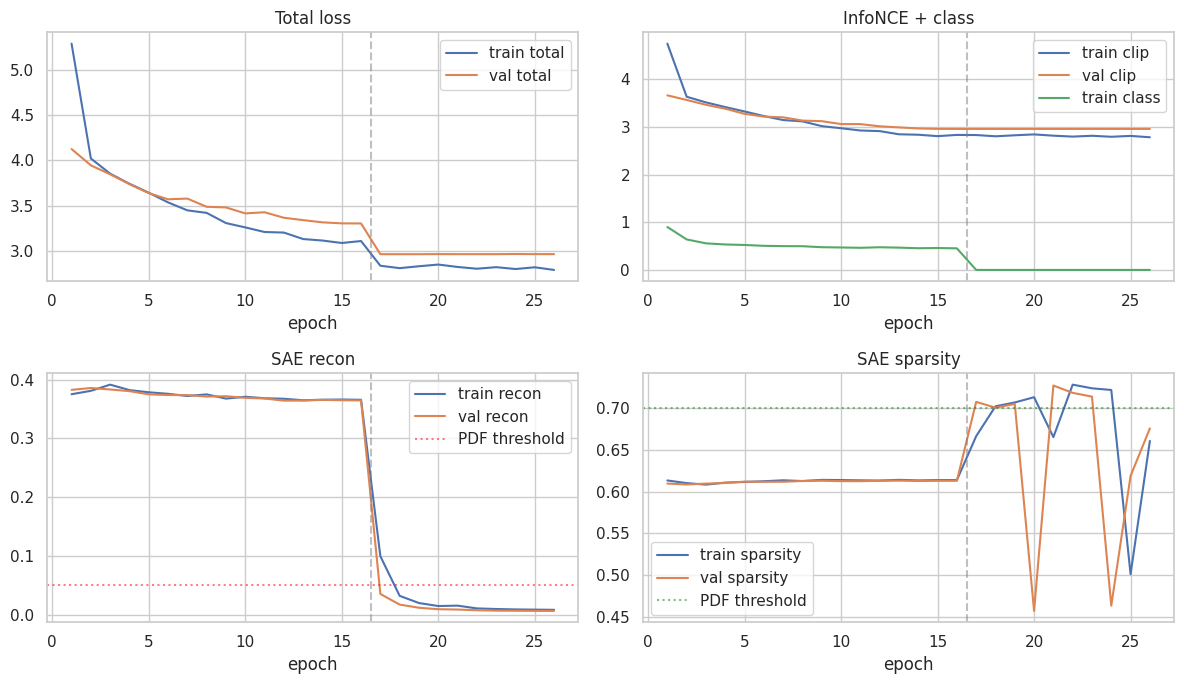

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
if len(history_df):
    axes[0, 0].plot(history_df['epoch'], history_df['train_total'], label='train total')
    axes[0, 0].plot(history_df['epoch'], history_df['val_total'], label='val total')
    axes[0, 0].axvline(PHASE1_EPOCHS + 0.5, ls='--', color='gray', alpha=0.5)
    axes[0, 0].set_title('Total loss'); axes[0, 0].legend(); axes[0, 0].set_xlabel('epoch')

    axes[0, 1].plot(history_df['epoch'], history_df['train_clip'], label='train clip')
    axes[0, 1].plot(history_df['epoch'], history_df['val_clip'], label='val clip')
    axes[0, 1].plot(history_df['epoch'], history_df['train_class'], label='train class')
    axes[0, 1].axvline(PHASE1_EPOCHS + 0.5, ls='--', color='gray', alpha=0.5)
    axes[0, 1].set_title('InfoNCE + class'); axes[0, 1].legend(); axes[0, 1].set_xlabel('epoch')

    axes[1, 0].plot(history_df['epoch'], history_df['train_recon_img'], label='train recon')
    axes[1, 0].plot(history_df['epoch'], history_df['val_recon_img'], label='val recon')
    axes[1, 0].axhline(PDF_THRESHOLDS['recon_visual_max'], ls=':', color='red', alpha=0.5, label='PDF threshold')
    axes[1, 0].axvline(PHASE1_EPOCHS + 0.5, ls='--', color='gray', alpha=0.5)
    axes[1, 0].set_title('SAE recon'); axes[1, 0].legend(); axes[1, 0].set_xlabel('epoch')

    axes[1, 1].plot(history_df['epoch'], history_df['train_sparsity_img'], label='train sparsity')
    axes[1, 1].plot(history_df['epoch'], history_df['val_sparsity_img'], label='val sparsity')
    axes[1, 1].axhline(PDF_THRESHOLDS['sparsity_visual_min'], ls=':', color='green', alpha=0.5, label='PDF threshold')
    axes[1, 1].axvline(PHASE1_EPOCHS + 0.5, ls='--', color='gray', alpha=0.5)
    axes[1, 1].set_title('SAE sparsity'); axes[1, 1].legend(); axes[1, 1].set_xlabel('epoch')

    fig.tight_layout()
    fig.savefig(FIG_DIR / 'training_curves_dual_head.png', dpi=160)
plt.show()

In [36]:
ckpt_path = final_ckpt_path
md5 = hashlib.md5(ckpt_path.read_bytes()).hexdigest()

best_phase1_path = CKPT_DIR / 'best_phase1.pt'
md5_phase1 = hashlib.md5(best_phase1_path.read_bytes()).hexdigest() if best_phase1_path.exists() else None

metrics = {
    'experiment': 'sit2_10_clip_sae_pseudolabel',
    'pdf_literal': True,
    'pdf_pragmatic_defendible': True,
    'evaluation_protocol': EVALUATION_PROTOCOL,
    'primary_kpi': PRIMARY_KPI,
    'pseudolabel_semantic_retrieval': True,
    'prompt_ensembling_centroid': True,
    'caption_level_reported_as_reference': True,
    'dual_head_architecture': True,
    'dual_phase_checkpointing': True,
    'tabular_fusion_no_s5p': True,
    'tabular_features': TABULAR_FEATURES,
    'tabular_n_features': len(TABULAR_FEATURES),
    'visual_fusion_dim': VISUAL_FUSION_DIM,
    'tab_dim': TAB_DIM,
    'aux_class_loss': True,
    'beta_class_constant': BETA_CLASS,
    'no_s5p_numeric_input': True,
    'no_raw_s5p_values_in_text': not bool(text_stats.get('raw_s5p_values_in_text', True)),
    'captions_per_image': 5,
    'caption_language': 'English',
    'multi_caption_recall': True,
    'prompts_per_class': PROMPTS_PER_CLASS,
    'effective_batch_size': BATCH_SIZE * GRAD_ACCUM_STEPS,
    'split': '70/15/15 stratified',
    'normalization': 'train only (bands and tabular)',
    'alpha_sae_max': ALPHA_SAE,
    'beta_class': BETA_CLASS,
    'min_unique_caption_ratio': MIN_UNIQUE_CAPTION_RATIO,
    'lambda_l1': LAMBDA_L1,
    'sae_dim': SAE_DIM,
    'proj_dim': PROJ_DIM,
    'hard_score_threshold': HARD_SCORE_THRESHOLD,
    'phase1_epochs': PHASE1_EPOCHS,
    'phase2_epochs': PHASE2_EPOCHS,
    'per_class_per_batch': PER_CLASS_PER_BATCH,
    'best_epoch_phase1': int(best_epoch_phase1),
    'best_val_clip_phase1': float(best_val_phase1),
    'best_epoch_phase2': int(best_epoch_phase2),
    'best_sae_score_phase2': float(best_sae_score),
    'final_checkpoint_phase': int(best_ckpt['phase']),
    'final_checkpoint_epoch': int(best_ckpt['epoch']),
    'retrieval_val_pseudolabel_centroid': retrieval_val_centroid,
    'retrieval_test_pseudolabel_centroid': retrieval_test_centroid,
    'retrieval_val_pseudolabel_prompt_pool': retrieval_val_prompt_pool,
    'retrieval_test_pseudolabel_prompt_pool': retrieval_test_prompt_pool,
    'retrieval_val_caption_level_reference': retrieval_val_capt,
    'retrieval_test_caption_level_reference': retrieval_test_capt,
    'sae_aux_test': test_emb['aux'],
    'sanity_test': {
        'class_prototype_acc': float(cls_acc_test),
        'knn_class_acc': float(knn_test),
        'alignment_cosine_mean': float(align_cos),
    },
    'pdf_thresholds': PDF_THRESHOLDS,
    'success_pdf_pseudolabel_centroid': success_pdf_pseudolabel_centroid,
    'success_pdf_prompt_pool': success_pdf_prompt_pool,
    'success_pdf_caption_level_reference': success_pdf_caption_level_ref,
    'prompt_texts': prompt_texts,
    'sae_post_hoc': sae_post_hoc_metrics,
    'sae_post_hoc_md5': sae_post_hoc_md5,
    'text_stats': text_stats,
    'checkpoint_md5': md5,
    'checkpoint_md5_phase1': md5_phase1,
}

with open(OUT_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
with open(OUT_DIR / 'checkpoint.md5', 'w') as f:
    f.write(md5)
np.savez_compressed(
    EMB_DIR / 'test_embeddings_pseudolabel.npz',
    image_dense=test_emb['image_dense'].numpy(),
    image_base=test_emb['image_base'].numpy(),
    text_dense=test_emb['text_dense'].numpy(),
    caption_owner=test_emb['caption_owner'].numpy(),
    label=test_emb['label'],
    label_idx=test_emb['label_idx'].numpy(),
    index=test_emb['index'],
)
print(json.dumps(metrics, indent=2))

{
  "experiment": "sit2_10_clip_sae_pseudolabel",
  "pdf_literal": true,
  "pdf_pragmatic_defendible": true,
  "evaluation_protocol": "image-to-text pseudo-label semantic retrieval",
  "primary_kpi": "recall@1_pseudolabel_centroid",
  "pseudolabel_semantic_retrieval": true,
  "prompt_ensembling_centroid": true,
  "caption_level_reported_as_reference": true,
  "dual_head_architecture": true,
  "dual_phase_checkpointing": true,
  "tabular_fusion_no_s5p": true,
  "tabular_features": [
    "ndvi",
    "ndbi",
    "scl_pct",
    "modis_AOD_047",
    "modis_WV",
    "era5_BLH",
    "era5_T2m",
    "era5_RH850",
    "wind_speed_tile",
    "visible_mean_tile",
    "nir_swir_contrast_tile",
    "texture_mean_tile"
  ],
  "tabular_n_features": 12,
  "visual_fusion_dim": 640,
  "tab_dim": 128,
  "aux_class_loss": true,
  "beta_class_constant": 0.6,
  "no_s5p_numeric_input": true,
  "no_raw_s5p_values_in_text": true,
  "captions_per_image": 5,
  "caption_language": "English",
  "multi_caption_reca

In [ ]:
# Guardar salidas como Kaggle Dataset para reutilizar sin reentrenar
import shutil
import subprocess
from datetime import datetime, timezone

KAGGLE_DATASET_ID = 'edwardsx/geovision-sit2-17-clip-sae-pseudolabel'
KAGGLE_DATASET_TITLE = 'GeoVision Sit2 17 CLIP SAE Pseudolabel Outputs'
UPLOAD_DIR = WORK_DIR / 'upload_sit2_17_clip_sae_pseudolabel'

if UPLOAD_DIR.exists():
    shutil.rmtree(UPLOAD_DIR)
UPLOAD_DIR.mkdir(parents=True, exist_ok=True)

assert OUT_DIR.exists(), f'No existe OUT_DIR: {OUT_DIR}'

for src in OUT_DIR.iterdir():
    dst = UPLOAD_DIR / src.name
    if src.is_dir():
        shutil.copytree(src, dst)
    else:
        shutil.copy2(src, dst)

files_manifest = []
for file_path in sorted(p for p in UPLOAD_DIR.rglob('*') if p.is_file() and p.name != 'dataset-metadata.json'):
    rel = file_path.relative_to(UPLOAD_DIR).as_posix()
    files_manifest.append({
        'path': rel,
        'size_bytes': int(file_path.stat().st_size),
        'md5': hashlib.md5(file_path.read_bytes()).hexdigest(),
    })

(UPLOAD_DIR / 'sit2_17_output_manifest.json').write_text(json.dumps({
    'created_at_utc': datetime.now(timezone.utc).isoformat(),
    'source_out_dir': str(OUT_DIR),
    'notebook': '17-clip-sae-pseudolabel.ipynb',
    'experiment': 'sit2_10_clip_sae_pseudolabel',
    'checkpoint_md5': metrics.get('checkpoint_md5'),
    'checkpoint_md5_phase1': metrics.get('checkpoint_md5_phase1'),
    'primary_kpi': metrics.get('primary_kpi'),
    'retrieval_test_pseudolabel_centroid': metrics.get('retrieval_test_pseudolabel_centroid'),
    'sae_aux_test': metrics.get('sae_aux_test'),
    'files': files_manifest,
}, indent=2))

(UPLOAD_DIR / 'dataset-metadata.json').write_text(json.dumps({
    'title': KAGGLE_DATASET_TITLE,
    'id': KAGGLE_DATASET_ID,
    'licenses': [{'name': 'CC-BY-SA-4.0'}],
}, indent=2))

print(f'Archivos preparados en: {UPLOAD_DIR}')
print(f'Total archivos: {len(files_manifest)}')
print(f'Tamaño total GB: {sum(f["size_bytes"] for f in files_manifest) / 1e9:.3f}')
print(f'Dataset destino: {KAGGLE_DATASET_ID}')

version_msg = 'sit2 notebook 17 outputs - CLIP SAE pseudolabel centroid KPI'
version_cmd = ['kaggle', 'datasets', 'version', '-p', str(UPLOAD_DIR), '-m', version_msg, '-r', 'zip']
create_cmd = ['kaggle', 'datasets', 'create', '-p', str(UPLOAD_DIR), '-r', 'zip']

version_result = subprocess.run(version_cmd, text=True, capture_output=True)
if version_result.returncode == 0:
    print(version_result.stdout)
    print('Dataset actualizado con nueva versión.')
else:
    print('No se pudo versionar; intento crear dataset nuevo.')
    print(version_result.stderr[-1000:])
    create_result = subprocess.run(create_cmd, text=True, capture_output=True)
    print(create_result.stdout)
    if create_result.returncode != 0:
        print(create_result.stderr[-2000:])
    create_result.check_returncode()
    print('Dataset creado.')
